In [63]:
from importlib import reload
import sys
import subprocess

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica
reload(pymodelica)


<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

# Run the simualtion

In [145]:
MODEL_EXE_NAME = "System_LMO_exe"
MODEL_FILE = "../System_LMO.mo"
MODEL_FILE_LIN = "../build/linearized_model.py"
MODEL_RESULT = f'../build/{MODEL_EXE_NAME}_res_init.mat'


EQUILIBRIUM_TIME = 20.0
# PARAMS = "../parameters/params_lmo_v1_mod_tes.txt"
PARAMS = "../parameters/params_lmo_v1_mod_absorber.txt"
# PARAMS = "../parameters/params_lmo_v1_default.txt"
# PARAMS = "../parameters/params.txt"


# Step 1. a fast simulation to reach equilibrium


-overrideFile=C:/Users/Tom/Documents/ThermalModel/parameters/params_lmo_v1_mod_absorber.txt

In [146]:
log = subprocess.run(
    [
        f"./{MODEL_EXE_NAME}",
        # "-lv=-LOG_STDOUT",
        f"-overrideFile={PARAMS}",
        "-startTime=0",
        f"-stopTime={EQUILIBRIUM_TIME}",
        "-stepSize=2e-4",
        "-tolerance=1e-8",
        "-s=dassl",
        "-w", # Show all warnings
        "-outputFormat=mat",
        f"-r={MODEL_EXE_NAME}_res_init.mat", # Result filename
        f"-l={EQUILIBRIUM_TIME}", ## Perform linearization
        '-deltaXLinearize=1e-9'
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log.stderr, log.stdout


('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [147]:
# Plot all C and G to check if the system is at equilibrium

filename_init = f'../build/{MODEL_EXE_NAME}_res_init.mat'
time_steps_init, data_init = pymodelica.load(filename_init)

pymodelica.mod_svg("../System_LMO.svg", "temp_image.svg", data_init, system_name="System_LMO", width=1500, display=True)

## Step 1b. Noise and Complex impedance

In [209]:
model = pymodelica.TESModel(MODEL_FILE_LIN, 
                 MODEL_FILE, 
                 MODEL_RESULT,
                 config={"L": 0.3e-6, "RL": 0.02}, 
                 f_min = 1, f_max = 100e3, points = 1000)

In [210]:
noise_current, frequencies = model.get_noise(RL_temperature = 0.2,
    noise_electronics = 3.2e-12,
    noise_flicker_corner = 20,
    noise_flicker_gamma = 1,
    index_cinput = -1)

Resolution (Sigma) in eV =  4499.887128856475


In [211]:
# Diagnosis
w, V = np.linalg.eig(model.model["A"])
W = np.linalg.inv(V)
k = np.argmax(w.real)
p = V[:, k] * W[k, :]

for name, val in sorted(zip(model.model["stateVars"], p), key=lambda x: abs(x[1]),
reverse=True):
    print(name, val, abs(val))

c2_T (0.7231876035074074+2.197920553031505e-22j) 0.7231876035074074
c10_T (0.22631426034843616-5.830890965070708e-23j) 0.22631426034843616
c3_T (0.03619369887491438-1.6154333801091156e-22j) 0.03619369887491438
c9_T (0.013734177113343094-5.846373636070278e-26j) 0.013734177113343094
c4_T (0.000497397200427837-9.853086558647118e-24j) 0.000497397200427837
c5_T (7.37178641845795e-05-9.140254560595364e-27j) 7.37178641845795e-05
L_i (-2.095977965527315e-06+1.9313071502225119e-22j) 2.095977965527315e-06
c1_T (1.2395783444686023e-06-1.9336667248022135e-22j) 1.2395783444686023e-06
c6_T (1.4790035544974195e-09-2.521468169173378e-25j) 1.4790035544974195e-09
c8_T (7.216482777821919e-12-1.1351775967156053e-27j) 7.216482777821919e-12
c7_T (4.631748002681255e-12-2.7553200574773637e-28j) 4.631748002681255e-12
CL_v (5.5892745753425924e-14-5.150153021697647e-30j) 5.5892745753425924e-14


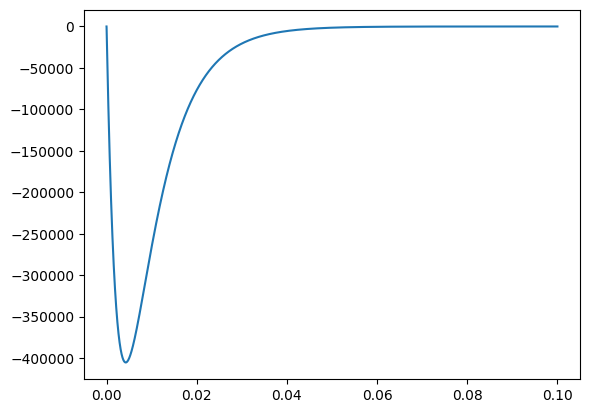

In [222]:
t,y = model.get_impulse(index_cinput = 10, T=np.linspace(0,0.1,10000))
# t,y = model.get_impulse2(energy=0.1*scipy.constants.e, index_input = 11, T=np.linspace(0,0.1,10000))
plt.plot(t, y[:,1])

Readout noise 6.334754453646691e-11
External Johnson noise 4.201783773306778e-12
TES Johnson noise 2.634416117439497e-12
TFN_1 2.434423929789739e-13
TFN_4 3.477344529915063e-12
TFN_7 3.242505707504191e-12
TFN_8 6.654831055082934e-13
TFN_14 1.1168254651528408e-13


Text(0, 0.5, 'Current noise [A/sqrtHz]')

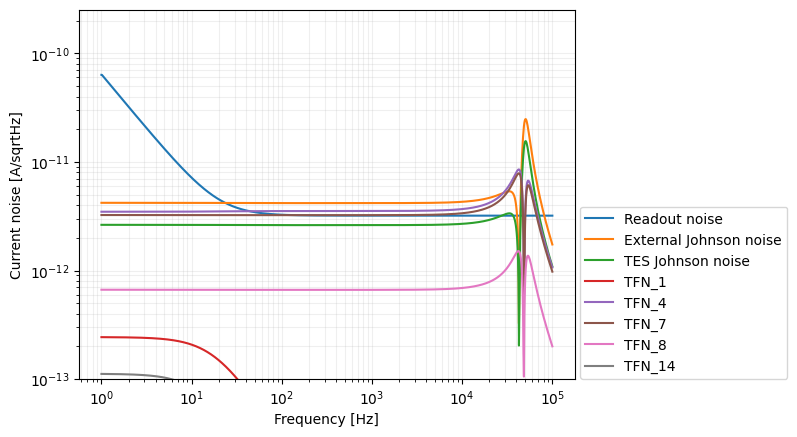

In [223]:
lower_lim = 1e-13
for key in noise_current:
    noise = abs(noise_current[key])
    if noise[0]<lower_lim:
        continue
    plt.loglog(frequencies, noise, label=key)
    print(key, noise[0])
plt.legend(loc=(1.01,0))
plt.ylim(lower_lim,)
plt.grid(which="both", alpha=0.2)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Current noise [A/sqrtHz]")

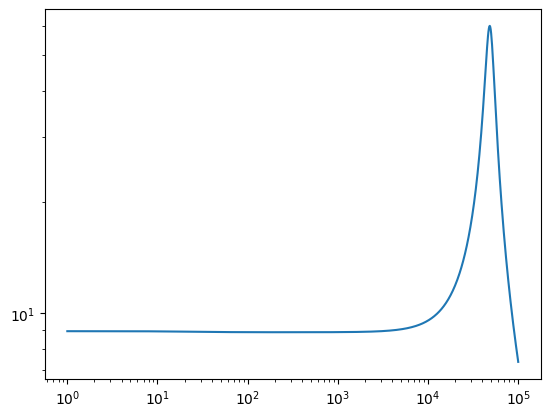

In [224]:
plt.loglog(model.frequencies, abs(model.get_dIdV()))

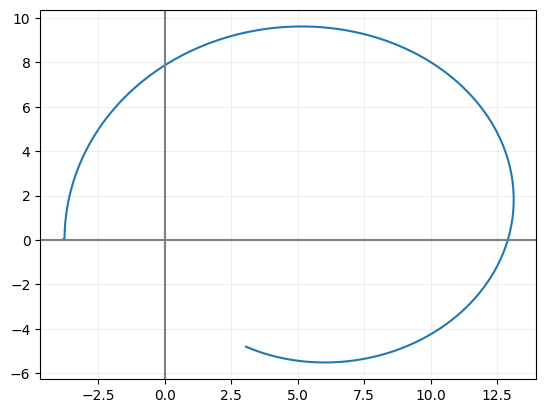

In [142]:
dIdV = model.get_dIdV()
plt.plot(dIdV.real, dIdV.imag)
plt.grid(alpha=0.2)
plt.axhline(0,color="grey")
plt.axvline(0,color="grey")

# Step 2: impulse response

Compile another simulation with fine resolution starting from the final values of Step 1

In [226]:

# Using -iif (Import Initial File) and -iit (Import Initial Time) to reset startTime = 0.0
log2 = subprocess.run(
    [
        f"./{MODEL_EXE_NAME}",
        f"-r={MODEL_EXE_NAME}_res_final.mat",
        f"-overrideFile={PARAMS}",
        "-s=dassl",
        "-w",
        "-startTime=0",
        "-stopTime=0.1",
        "-stepSize=1e-6",
        "-tolerance=1e-8",
        f"-iif={MODEL_EXE_NAME}_res_init.mat",
        f"-iit={EQUILIBRIUM_TIME}",
        "-lv=-LOG_STDOUT",
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log2.stderr, log2.stdout

('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [227]:
filename = f'../build/{MODEL_EXE_NAME}_res_final.mat'

time_steps, data = pymodelica.load(filename)
print(data.keys())

dict_keys(['CL.v', 'L.i', 'c1.T', 'c10.T', 'c2.T', 'c3.T', 'c4.T', 'c5.T', 'c6.T', 'c7.T', 'c8.T', 'c9.T', 'der(CL.v)', 'der(L.i)', 'der(c1.T)', 'der(c10.T)', 'der(c2.T)', 'der(c3.T)', 'der(c4.T)', 'der(c5.T)', 'der(c6.T)', 'der(c7.T)', 'der(c8.T)', 'der(c9.T)', 'C1', 'C10', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'CL.i', 'G1', 'G10', 'G11', 'G12', 'G13', 'G14', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'GND.p.i', 'GND.p.v', 'HeatSource.port.Q_flow', 'HeatSource1.port.Q_flow', 'L.v', 'RL.LossPower', 'RL.R_actual', 'RL.i', 'c1.P_Joule', 'c1.R', 'c1.cp', 'c1.heatPort.Q_flow', 'c1.v', 'c10.cp', 'c10.port.Q_flow', 'c2.cp', 'c2.port.Q_flow', 'c3.cp', 'c3.port.Q_flow', 'c4.cp', 'c4.port.Q_flow', 'c5.cp', 'c5.port.Q_flow', 'c6.cp', 'c6.port.Q_flow', 'c7.cp', 'c7.port.Q_flow', 'c8.cp', 'c8.port.Q_flow', 'c9.cp', 'c9.port.Q_flow', 'edep_film.y', 'edep_target.y', 'fixedTemperature.port.Q_flow', 'g1.Q_flow', 'g10.Q_flow', 'g11.Q_flow', 'g12.Q_flow', 'g13.Q_flow', 'g14.Q_flow', 'g2.Q

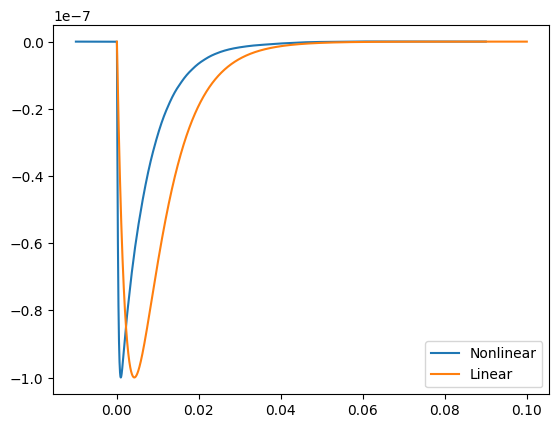

In [235]:
y_nonlinear = data['c1.i'] - np.mean(data['c1.i'][:10])
y_linear = y[:,1]/max(abs(y[:,1]))
plt.plot(time_steps-0.01, y_nonlinear, label="Nonlinear")
plt.plot(t, y_linear * max(abs(y_nonlinear)), label="Linear")
plt.legend()

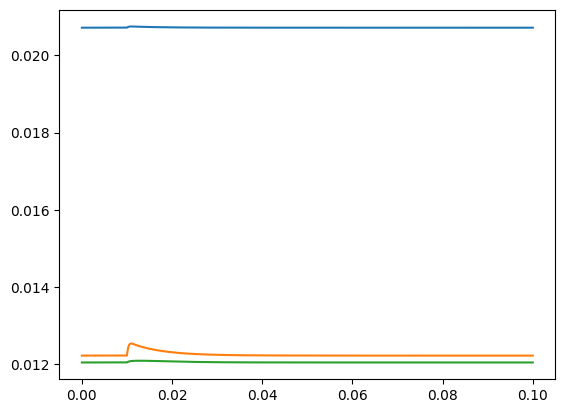

In [236]:
plt.plot(time_steps, data['T1'])
plt.plot(time_steps, data['T2'])
plt.plot(time_steps, data['T10'])